In [20]:
import pandas as pd

df=pd.read_csv('../datasets/processed/DSGP1.csv')
df.head()

,T2M,T2M_RANGE,RH2M,GWETTOP,Cluster_Label,PCACOMP1,PCACOMP2,PCACOMP3
0,24.166667,6.551333,77.967333,0.587333,1,-1.780082,-0.433574,-1.627375
1,24.581667,5.710000,79.531667,0.565000,1,-1.479069,-0.312703,-0.859869
2,24.756000,6.982000,80.534000,0.611000,1,-1.336950,-0.412495,-0.381413
3,25.878333,8.392500,71.654167,0.480000,0,-1.730179,-0.101366,-1.368670
4,27.590000,7.645000,72.365000,0.433333,0,-1.080854,-0.187889,0.928905


In [21]:
from sklearn.model_selection import GridSearchCV, train_test_split,StratifiedKFold,cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from imblearn.combine import SMOTETomek
from sklearn.metrics import accuracy_score
from collections import Counter


X = df.drop(["Cluster_Label"], axis=1)
Y = df["Cluster_Label"]

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42,stratify=Y)


smote_tomek = SMOTETomek(random_state=42)
X_train_resampled, y_train_resampled = smote_tomek.fit_resample(X_train, y_train)
print("Class distribution after SMOTETomek:", Counter(y_train_resampled))


rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [200, 250, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [5, 10, 15],
    'max_features': ['sqrt', 'log2'],
}


grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=5, n_jobs=-1, verbose=2, scoring='accuracy')

grid_search.fit(X_train_resampled, y_train_resampled)


print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

y_train_pred = best_model.predict(X_train_resampled)
y_val_pred = best_model.predict(X_test)

training_accuracy = accuracy_score(y_train_resampled, y_train_pred)
testing_accuracy = accuracy_score(y_test, y_val_pred)

print(f"Training Accuracy: {training_accuracy * 100:.2f}%")
print(f"Validation Accuracy: {testing_accuracy * 100:.2f}%")


Class distribution after SMOTETomek: Counter({0: 396, 1: 396})
Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200}
Training Accuracy: 99.12%
Validation Accuracy: 97.41%


In [22]:
X.head()

,T2M,T2M_RANGE,RH2M,GWETTOP,PCACOMP1,PCACOMP2,PCACOMP3
0,24.166667,6.551333,77.967333,0.587333,-1.780082,-0.433574,-1.627375
1,24.581667,5.710000,79.531667,0.565000,-1.479069,-0.312703,-0.859869
2,24.756000,6.982000,80.534000,0.611000,-1.336950,-0.412495,-0.381413
3,25.878333,8.392500,71.654167,0.480000,-1.730179,-0.101366,-1.368670
4,27.590000,7.645000,72.365000,0.433333,-1.080854,-0.187889,0.928905


In [23]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_val_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97        94
           1       0.97      0.98      0.97        99

    accuracy                           0.97       193
   macro avg       0.97      0.97      0.97       193
weighted avg       0.97      0.97      0.97       193



In [24]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_val_pred))

[[91  3]
 [ 2 97]]


In [25]:
import numpy as np

193


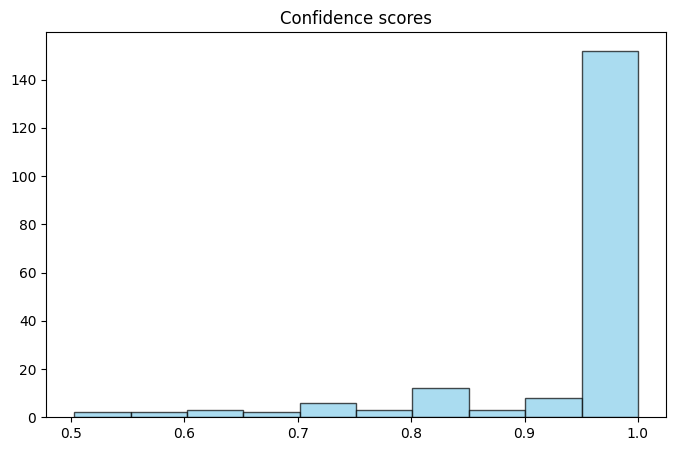

In [26]:
predicted_probablity=best_model.predict_proba(X_test)
predict_class=np.argmax(predicted_probablity)
confidence=[]
for val in predicted_probablity:
    confidence.append(np.max(val))
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.hist(confidence, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Confidence scores')
print(len(confidence))

In [27]:
list_threshold=[]
for i in range(5,20,5):
    threshold=np.percentile(confidence,i)
    print(f'{i}th percentile: {threshold}')
    list_threshold.append(threshold)


5th percentile: 0.7148901067886363
10th percentile: 0.814577531562005
15th percentile: 0.8442000231192957


0.6451686646686647
0.525762153695977
0.5030002246205809
0.5770428370648959
0.5554679267241185
0.6851754071092307
0.6234486790986792
0.6921745248215834
0.7067016863855099
0.6426451437451436
10


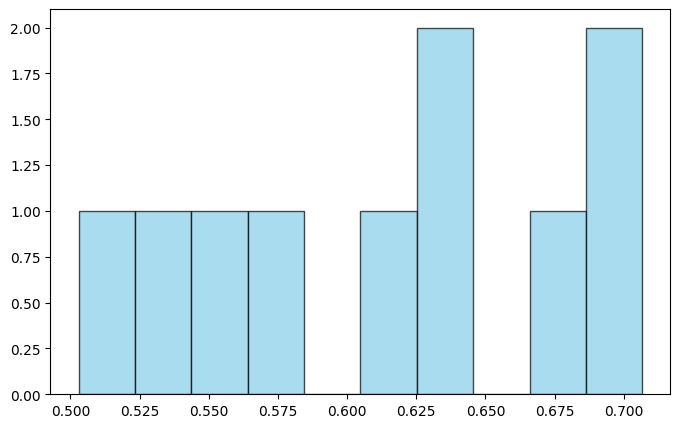

In [28]:

lowones5th=[]
for values in confidence:
    if values<0.71:
        print(values)
        lowones5th.append(values)

plt.figure(figsize=(8, 5))
plt.hist(lowones5th, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
print(len(lowones5th))

0.740276564530241
0.7440496227628581
0.6451686646686647
0.525762153695977
0.5030002246205809
0.7203490537240538
0.5770428370648959
0.5554679267241185
0.6851754071092307
0.6234486790986792
0.7303634551722787
0.6921745248215834
0.7718550199800199
0.7067016863855099
0.6426451437451436
0.7387949338243454
0.7872207126207127
0.7770942529692527
18


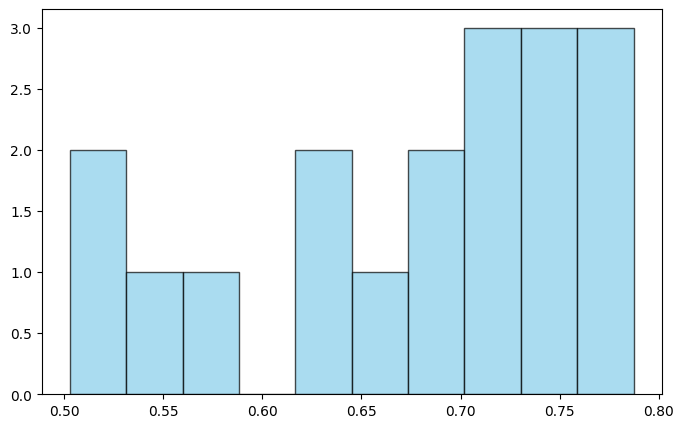

In [29]:

lowones10th=[]
for values in confidence:
    if values<0.80:
        print(values)
        lowones10th.append(values)

plt.figure(figsize=(8, 5))
plt.hist(lowones10th, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
print(len(lowones10th))

0.740276564530241
0.8994206349206354
0.8449612586415993
0.8196238761238759
0.7440496227628581
0.8287358030858029
0.6451686646686647
0.525762153695977
0.5030002246205809
0.8029276718293745
0.9439319014319015
0.7203490537240538
0.9035007145632146
0.5770428370648959
0.9457002997002999
0.5554679267241185
0.6851754071092307
0.6234486790986792
0.7303634551722787
0.6921745248215834
0.7718550199800199
0.9248984210234211
0.8144012931512928
0.8232731137756288
0.8152824852048535
0.9024851676101677
0.7067016863855099
0.6426451437451436
0.8303577312565316
0.8411550810300809
0.7387949338243454
0.8889606296481296
0.8312216394716393
0.7872207126207127
0.9459246059496058
0.890249114774115
0.7770942529692527
0.8281363775113771
0.9476611999112001
0.9372149794649792
0.8207976869621608
41


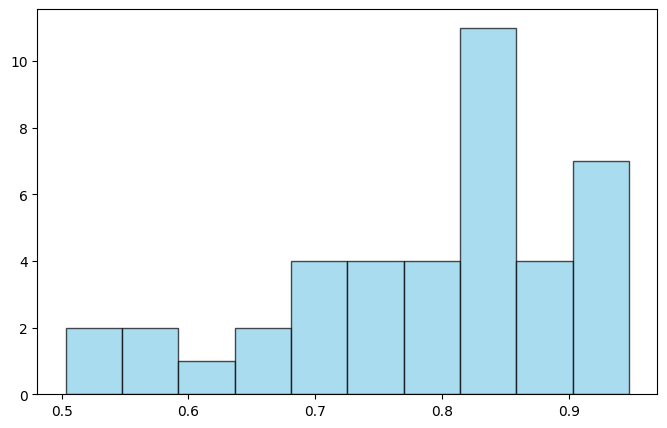

In [30]:

lowones15th=[]
for values in confidence:
    if values<0.95:
        print(values)
        lowones15th.append(values)

plt.figure(figsize=(8, 5))
plt.hist(lowones15th, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
print(len(lowones15th))

In [31]:
36/193

0.18652849740932642

In [32]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier()
scores = cross_val_score(rf_classifier, X, Y, cv=5, scoring='f1_macro')
print("Cross-Validation F1-Scores:", scores)
print("Mean F1-Score:", scores.mean())

Cross-Validation F1-Scores: [0.96366815 0.97409326 0.98445429 0.98442921 0.98444092]
Mean F1-Score: 0.9782171651361837


In [33]:
from sklearn.preprocessing import StandardScaler



X=df.drop(['Cluster_Label'],axis=1)

scaler=StandardScaler()
X_scale=scaler.fit_transform(X)
Scaled_df=pd.DataFrame(X_scale,columns=X.columns)
Scaled_df.head()

,T2M,T2M_RANGE,RH2M,GWETTOP,PCACOMP1,PCACOMP2,PCACOMP3
0,-1.792869,-0.070642,-0.015286,0.051606,-1.780082,-0.433574,-1.627375
1,-1.506076,-0.484933,0.185296,-0.073296,-1.479069,-0.312703,-0.859869
2,-1.385600,0.141427,0.313818,0.183966,-1.336950,-0.412495,-0.381413
3,-0.609990,0.835988,-0.824773,-0.548671,-1.730179,-0.101366,-1.368670
4,0.572889,0.467903,-0.733629,-0.809661,-1.080854,-0.187889,0.928905


In [34]:
df1 = pd.concat([df['Cluster_Label'], Scaled_df], axis=1)
df1.head()

,Cluster_Label,T2M,T2M_RANGE,RH2M,GWETTOP,PCACOMP1,PCACOMP2,PCACOMP3
0,1,-1.792869,-0.070642,-0.015286,0.051606,-1.780082,-0.433574,-1.627375
1,1,-1.506076,-0.484933,0.185296,-0.073296,-1.479069,-0.312703,-0.859869
2,1,-1.385600,0.141427,0.313818,0.183966,-1.336950,-0.412495,-0.381413
3,0,-0.609990,0.835988,-0.824773,-0.548671,-1.730179,-0.101366,-1.368670
4,0,0.572889,0.467903,-0.733629,-0.809661,-1.080854,-0.187889,0.928905


In [35]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
dt_model.fit(X_train_resampled, y_train_resampled)

y_pred = dt_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9740932642487047
              precision    recall  f1-score   support

           0       0.99      0.96      0.97        94
           1       0.96      0.99      0.98        99

    accuracy                           0.97       193
   macro avg       0.97      0.97      0.97       193
weighted avg       0.97      0.97      0.97       193



In [36]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[90  4]
 [ 1 98]]


In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Flatten,Input
from sklearn.model_selection import train_test_split

X=df1.drop('Cluster_Label',axis=1)
Y=df1['Cluster_Label']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X_train, y_train)


model = Sequential([
    Input(shape=(7,)),
    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.4),
    Dense(16, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])


model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_resampled, y_resampled, validation_data=(X_test, y_test), epochs=30, batch_size=64)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.5076 - loss: 0.7703 - val_accuracy: 0.8238 - val_loss: 0.5908
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6317 - loss: 0.6465 - val_accuracy: 0.8860 - val_loss: 0.4827
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7684 - loss: 0.5071 - val_accuracy: 0.9171 - val_loss: 0.4080
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8014 - loss: 0.4572 - val_accuracy: 0.9223 - val_loss: 0.3479
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8523 - loss: 0.3920 - val_accuracy: 0.9585 - val_loss: 0.2975
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8875 - loss: 0.3435 - val_accuracy: 0.9637 - val_loss: 0.2557
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9130 - loss: 0.2898 - val_accuracy: 0.9845 - val_loss: 0.2192
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9368 - loss: 0.2520 - val_accuracy: 0.9845 - v

In [38]:
from sklearn.metrics import classification_report
import numpy as np

y_pred=model.predict(X_test)
 
y_pred_labels = (y_pred > 0.5).astype(int)  
print(classification_report(y_test, y_pred_labels))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        80
           1       1.00      0.99      1.00       113

    accuracy                           0.99       193
   macro avg       0.99      1.00      0.99       193
weighted avg       0.99      0.99      0.99       193



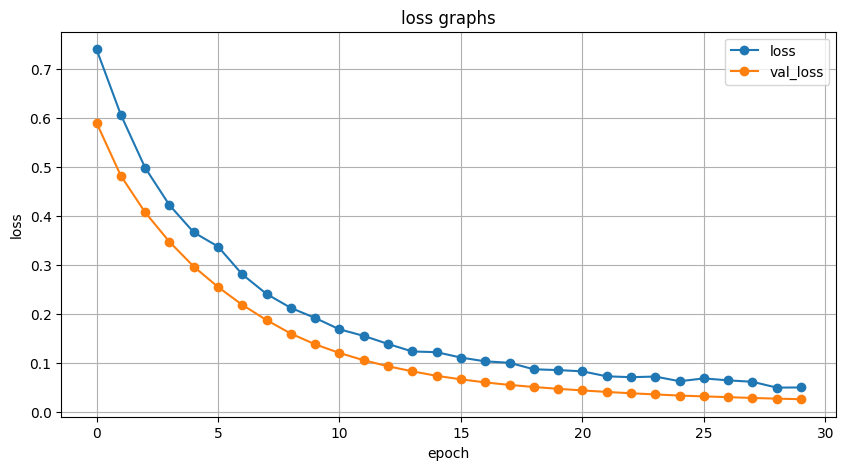

In [40]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='loss', marker='o')
plt.plot(history.history['val_loss'], label='val_loss',marker='o')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title("loss graphs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pickle
with open('irrigation_optimization_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)